# 👩‍💻 Use an LSTM for Time Series Forecasting

## 📋 Overview
In this lab, you'll build and implement a Long Short-Term Memory (LSTM) neural network for time series forecasting. Working with synthetic sine wave data, you'll learn how to prepare sequential data, construct an LSTM model in PyTorch, train it effectively, and evaluate its predictions. By the end of this lab, you'll have created a model that can predict future values in a time series pattern - a technique widely used in stock market prediction, weather forecasting, and demand planning.

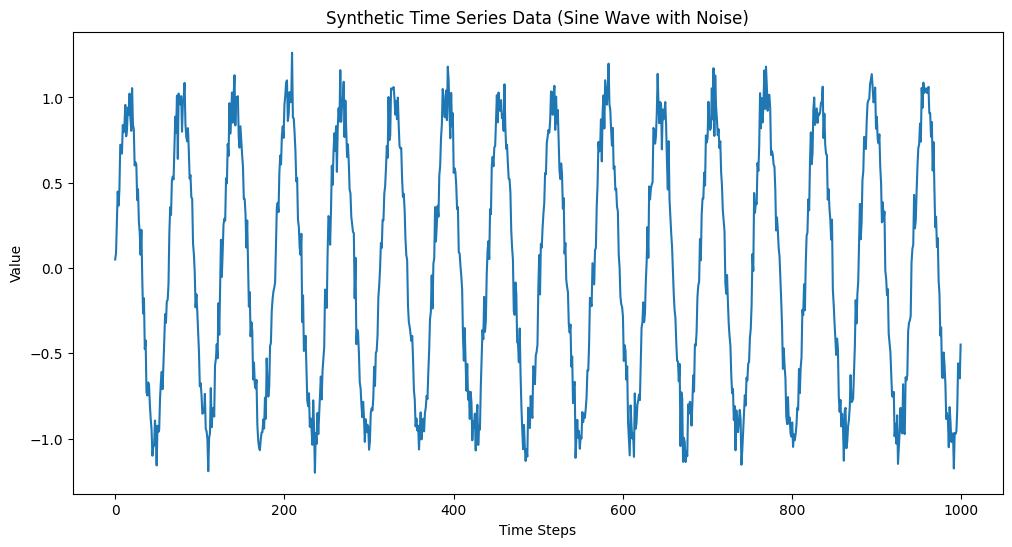

In [1]:
# Starter code: Imports and data generation
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Generate synthetic time series data (sine wave)
np.random.seed(42)
time_steps = np.linspace(0, 100, 1000)
data = np.sin(time_steps) + np.random.normal(0, 0.1, size=len(time_steps))

# Plot the data to visualize
plt.figure(figsize=(12, 6))
plt.plot(data)
plt.title("Synthetic Time Series Data (Sine Wave with Noise)")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.show()

## Task 1: Prepare Sequential Data
**Context:** Time series forecasting requires data to be formatted as sequences with input windows and target values. For LSTMs, we need to structure our data as sequences of past observations to predict future values.

**Steps:**

1. Create a function to transform the time series data into sequences

    - Use the `np.array` function to store your sequences
    - Consider how a sliding window approach works with parameters like `seq_length`
    - What's the appropriate target for each sequence? (Think about forecasting one step ahead)

2. Split the data into training and testing sets

    - Use `torch.tensor()` to convert numpy arrays to PyTorch tensors
    - Remember to set the correct data type (`dtype=torch.float32`)

3. Create a custom dataset class for better data handling

    - Implement the `__len__` and `__getitem__` methods required by PyTorch's Dataset
    - Format each sample as a sequence-target pair

In [1]:
# Task 1: Prepare Sequential Data
def create_sequences(data, seq_length):
    """
    Transform a 1D time series array into (sequence, target) pairs.
    """
    sequences = []
    targets = []

    for i in range(len(data) - seq_length):
        seq = data[i : i + seq_length]
        target = data[i + seq_length]   # one-step-ahead prediction
        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)
    
# Set sequence length (window size for prediction)
seq_length = 20

# Create sequences from time series data
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Example synthetic data
t = np.linspace(0, 200, 2000)
data = np.sin(t)

seq_length = 20

X, y = create_sequences(data, seq_length)

# Split data into training and testing sets (80/20 split)
train_size = int(0.8 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


# Create PyTorch dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]
    
# Create data loaders
batch_size = 32

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Task 2: Design the LSTM Model
**Context:** LSTMs are particularly effective for time-series because they can remember patterns over long sequences. You'll build a model that processes sequence data and outputs predictions.

**Steps:**

1. Create an LSTM class inheriting from `nn.Module`

    - Consider the appropriate input size, hidden size, and number of layers
    - Use `nn.LSTM` for the recurrent layers
    - Use `nn.Linear` for the output layer

2. Initialize the model parameters

    - Set the size of hidden states
    - Configure the number of LSTM layers
    - Set the output dimension based on your prediction task

3. Implement the forward pass

    - Initialize hidden states using torch.zeros
    - Pass input through the LSTM layer with proper hidden state handling
    - Extract the relevant output and pass through final linear layer

In [2]:
# Task 2: Design the LSTM Model
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)

        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))

        # Extract last time step output
        last_output = out[:, -1, :]

        # Final prediction
        out = self.fc(last_output)
        return out
        
# Initialize the model with appropriate parameters
input_size = 1          # univariate time series
hidden_size = 64        # common choice for LSTM
num_layers = 2          # stacked LSTMs
output_size = 1         # one-step prediction

model = LSTMModel(input_size, hidden_size, num_layers, output_size)
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## Task 3: Train the LSTM Model
**Context:** Training an LSTM involves feeding sequences, calculating loss, and updating weights through backpropagation. The process requires careful monitoring to ensure the model is learning effectively.

**Steps:**

1. Define loss function and optimizer

    - Use `nn.MSELoss()` for regression tasks
    - Configure `optim.Adam` with an appropriate learning rate

2. Create a training loop

    - Iterate through your training data in batches
    - Zero gradients with `optimizer.zero_grad()`
    - Compute model outputs and loss
    - Call `loss.backward()` and `optimizer.step()` to update weights

3. Track and display training progress

    - Store loss values for plotting
    - Print progress at regular intervals

Epoch [10/30], Loss: 0.000000
Epoch [20/30], Loss: 0.000004
Epoch [30/30], Loss: 0.000000


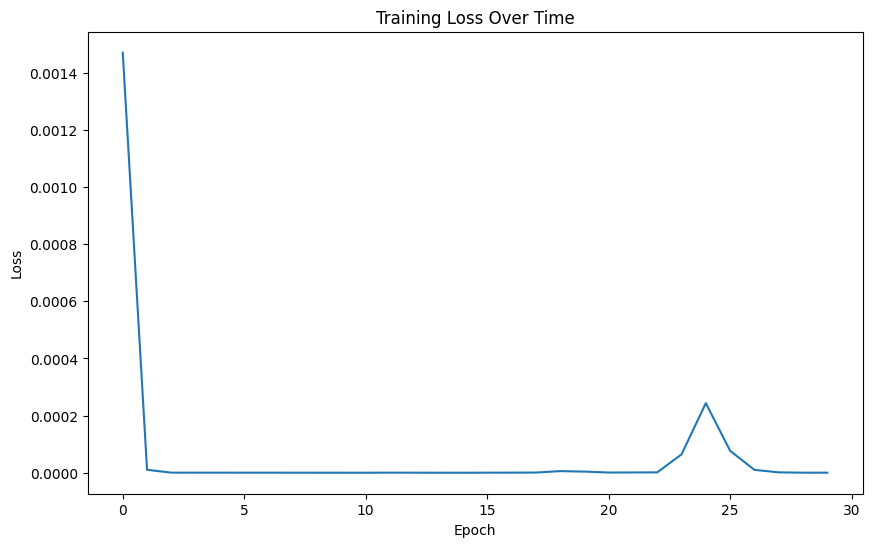

In [5]:
# Task 3: Train the LSTM Model

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Set training parameters
num_epochs = 30
batch_size = 32

# Initialize lists to store metrics
train_losses = []

# Training loop
num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for sequences, targets in train_loader:
        # LSTM expects input shape: (batch, seq_length, input_size)
        sequences = sequences.unsqueeze(-1)   # add input_size=1 dimension
        targets = targets.unsqueeze(-1)

        optimizer.zero_grad()

        outputs = model(sequences)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Task 4: Evaluate and Visualize Predictions
**Context:** After training, you need to evaluate how well your model can predict future values and visualize the results to understand its performance.

**Steps:**

1. Set the model to evaluation mode

    - Use `model.eval()` to disable dropout and other training-specific behaviors
    - Use `torch.no_grad()` context manager to disable gradient calculation

2. Generate predictions on test data

    - Feed test sequences through the model
    - Convert predictions back to numpy arrays for visualization

3. Create visualization comparing predictions with actual values

    - Use `matplotlib.pyplot` to plot actual vs. predicted values
    - Add appropriate labels and title to clarify the visualization

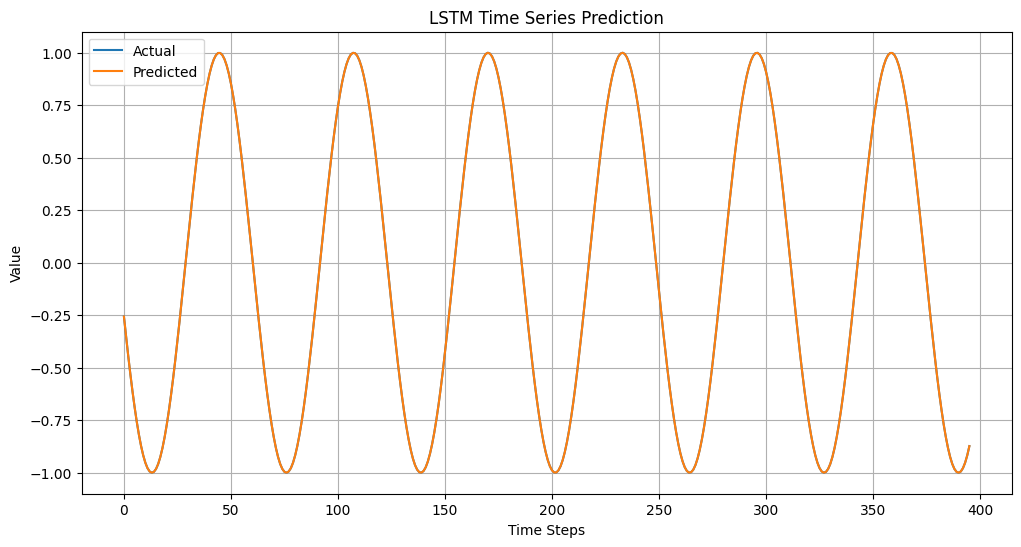

MSE: 0.000000
MAE: 0.000237


In [8]:
# Task 4: Evaluate and Visualize Predictions

# Set model to evaluation mode
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for sequences, targets in test_loader:
        sequences = sequences.unsqueeze(-1)
        outputs = model(sequences)

        predictions.append(outputs.squeeze().cpu().numpy())
        actuals.append(targets.cpu().numpy())

# Convert list-of-arrays → single flat array
predictions = np.concatenate(predictions).ravel()
actuals = np.concatenate(actuals).ravel()


# Create visualization
plt.figure(figsize=(12, 6))
plt.plot(actuals, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title('LSTM Time Series Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


# Calculate error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")